# Phase 11: Advanced Genre Insights

This phase extends the genre analysis by examining genre popularity, rating performance, and genre-level trends across different periods.

## Objectives

- Identify the most popular movie genres
- Compare average ratings across genres
- Analyze genre performance across decades
- Identify high-volume and high-rated genres
- Generate visual insights for the final project

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/movies_feature_engineered.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (569655, 46)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,genre_list,averageRating,numVotes,year,...,genre_sport,genre_talk_show,genre_thriller,genre_war,genre_western,runtime_category,rating_category,log_votes,popularity_category,rating_popularity_score
0,tt0000574,movie,The Story of the Kelly Gang,1906,70.0,"Action,Adventure,Biography","['Action', 'Adventure', 'Biography']",6.0,1084.0,1906,...,0,0,0,0,0,Short,Average,6.989335,Popular,41.936012
1,tt0000591,movie,The Prodigal Son,1907,90.0,Drama,['Drama'],4.8,40.0,1907,...,0,0,0,0,0,Medium,Low,3.713572,Low,17.825146
2,tt0000615,movie,Robbery Under Arms,1907,NaN,Drama,['Drama'],3.4,36.0,1907,...,0,0,0,0,0,Unknown,Low,3.610918,Low,12.277121
3,tt0000630,movie,Hamlet,1908,NaN,Drama,['Drama'],3.0,42.0,1908,...,0,0,0,0,0,Unknown,Low,3.761200,Low,11.283600
4,tt0000675,movie,Don Quijote,1908,NaN,Drama,['Drama'],3.8,32.0,1908,...,0,0,0,0,0,Unknown,Low,3.496508,Low,13.286729


In [8]:
# Select numerical features for clustering

cluster_features = [
    "averageRating",
    "numVotes",
    "runtimeMinutes",
    "year"
]

cluster_df = df[cluster_features].copy()

print("Missing values before cleaning:")
display(cluster_df.isna().sum())

Missing values before cleaning:


averageRating     231990
numVotes          231990
runtimeMinutes    128235
year                   0
dtype: int64

In [9]:
# Remove rows with missing values
cluster_df = cluster_df.dropna().copy()

print("Dataset shape after removing missing values:")
print(cluster_df.shape)

display(cluster_df.describe().round(2))

Dataset shape after removing missing values:
(307142, 4)


,averageRating,numVotes,runtimeMinutes,year
count,307142.00,307142.00,307142.00,307142.00
mean,6.12,4197.81,93.81,1997.89
std,1.35,40495.89,24.28,26.09
min,1.00,5.00,1.00,1900.00
25%,5.30,25.00,80.00,1982.00
50%,6.20,84.00,91.00,2009.00
75%,7.00,415.00,104.00,2018.00
max,10.00,3226746.00,400.00,2026.00


In [10]:
# Reduce extreme skewness in vote counts

cluster_df["log_numVotes"] = np.log1p(
    cluster_df["numVotes"]
)

features_for_clustering = [
    "averageRating",
    "log_numVotes",
    "runtimeMinutes",
    "year"
]

X = cluster_df[features_for_clustering]

display(X.describe().round(2))

,averageRating,log_numVotes,runtimeMinutes,year
count,307142.00,307142.00,307142.00,307142.00
mean,6.12,4.87,93.81,1997.89
std,1.35,2.08,24.28,26.09
min,1.00,1.79,1.00,1900.00
25%,5.30,3.26,80.00,1982.00
50%,6.20,4.44,91.00,2009.00
75%,7.00,6.03,104.00,2018.00
max,10.00,14.99,400.00,2026.00


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [12]:
# Standardize features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature shape:", X_scaled.shape)
display(
    pd.DataFrame(
        X_scaled,
        columns=features_for_clustering
    ).head()
)

Scaled feature shape: (307142, 4)


,averageRating,log_numVotes,runtimeMinutes,year
0,-0.092098,1.020850,-0.980491,-3.52224
1,-0.982711,-0.556752,-0.156751,-3.48391
2,-0.908494,-0.217096,1.078858,-3.44558
3,-1.428018,-0.568644,-2.010165,-3.40725
4,-2.170196,-0.723518,-1.474734,-3.36892


In [13]:
from sklearn.cluster import KMeans
print("KMeans imported successfully!")

KMeans imported successfully!


In [14]:
# Final K-Means clustering

optimal_k = 5

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

print("Final clustering completed.")
print("Number of clusters:", optimal_k)

/Users/abhimanyusingh/Desktop/Movie Genre Evolution Analyzer /.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/abhimanyusingh/Desktop/Movie Genre Evolution Analyzer /.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/abhimanyusingh/Desktop/Movie Genre Evolution Analyzer /.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/abhimanyusingh/Desktop/Movie Genre Evolution Analyzer /.venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/abhimanyusingh/Desktop/Movie Genre Evolution Analyzer /.venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = clo

Final clustering completed.
Number of clusters: 5


In [15]:
# Add cluster labels to the cleaned dataset

cluster_df["cluster"] = cluster_labels

print("Cluster labels added successfully.")
print("Dataset shape:", cluster_df.shape)

display(cluster_df.head())

Cluster labels added successfully.
Dataset shape: (307142, 6)


,averageRating,numVotes,runtimeMinutes,year,log_numVotes,cluster
0,6.0,1084.0,70.0,1906,6.989335,2
1,4.8,40.0,90.0,1907,3.713572,2
5,4.9,82.0,120.0,1908,4.418841,2
7,4.2,39.0,45.0,1909,3.688879,2
16,3.2,28.0,58.0,1910,3.367296,2


In [16]:
# Profile the movie clusters
cluster_profiles = (
    cluster_df
    .groupby("cluster")[features_for_clustering]
    .mean()
    .round(2)
)
print("Cluster Profiles:")
display(cluster_profiles)

Cluster Profiles:


,averageRating,log_numVotes,runtimeMinutes,year
cluster,,,,
0,4.52,4.78,90.68,2009.43
1,6.43,8.18,103.66,2005.62
2,5.95,4.32,84.57,1957.43
3,7.19,3.53,82.20,2012.15
4,6.59,4.68,141.74,2002.82


In [17]:
cluster_sizes = (
    cluster_df["cluster"]
    .value_counts()
    .sort_index()
)

print("Number of movies in each cluster:")
display(cluster_sizes.to_frame("movie_count"))

Number of movies in each cluster:


,movie_count
cluster,
0,71281
1,50980
2,65498
3,90638
4,28745


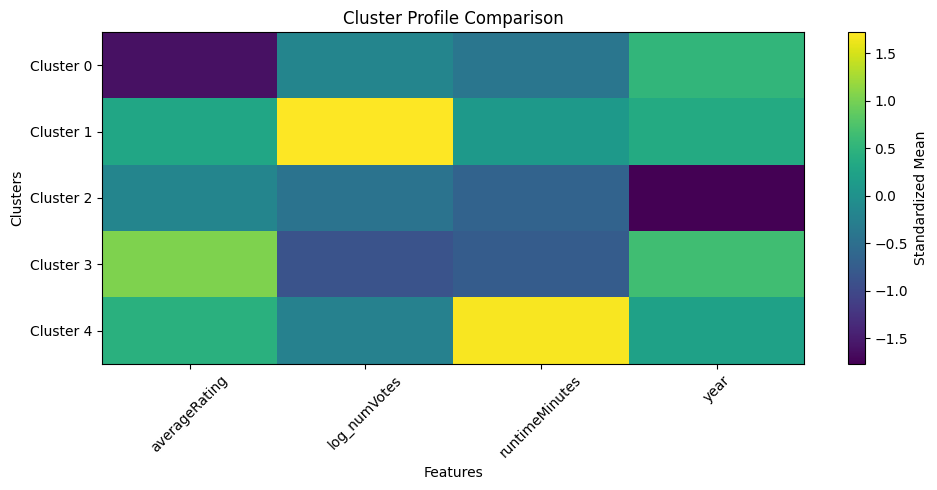

In [18]:
# Visualize cluster profiles

cluster_profile_scaled = (
    cluster_profiles - cluster_profiles.mean()
) / cluster_profiles.std()

plt.figure(figsize=(10, 5))

plt.imshow(
    cluster_profile_scaled,
    aspect="auto"
)

plt.colorbar(label="Standardized Mean")

plt.xticks(
    range(len(cluster_profile_scaled.columns)),
    cluster_profile_scaled.columns,
    rotation=45
)

plt.yticks(
    range(len(cluster_profile_scaled.index)),
    [f"Cluster {i}" for i in cluster_profile_scaled.index]
)

plt.title("Cluster Profile Comparison")
plt.xlabel("Features")
plt.ylabel("Clusters")

plt.tight_layout()
plt.show()

In [19]:
# Identify the dominant characteristics of each cluster

for cluster in sorted(cluster_df["cluster"].unique()):
    profile = cluster_profiles.loc[cluster]

    print(f"\nCluster {cluster}")
    print("-" * 40)
    print(f"Average Rating : {profile['averageRating']:.2f}")
    print(f"Log Votes      : {profile['log_numVotes']:.2f}")
    print(f"Runtime        : {profile['runtimeMinutes']:.2f} min")
    print(f"Average Year   : {profile['year']:.0f}")


Cluster 0
----------------------------------------
Average Rating : 4.52
Log Votes      : 4.78
Runtime        : 90.68 min
Average Year   : 2009

Cluster 1
----------------------------------------
Average Rating : 6.43
Log Votes      : 8.18
Runtime        : 103.66 min
Average Year   : 2006

Cluster 2
----------------------------------------
Average Rating : 5.95
Log Votes      : 4.32
Runtime        : 84.57 min
Average Year   : 1957

Cluster 3
----------------------------------------
Average Rating : 7.19
Log Votes      : 3.53
Runtime        : 82.20 min
Average Year   : 2012

Cluster 4
----------------------------------------
Average Rating : 6.59
Log Votes      : 4.68
Runtime        : 141.74 min
Average Year   : 2003


In [20]:
# Summarize each cluster

cluster_summary = (
    cluster_df
    .groupby("cluster")
    .agg(
        movie_count=("cluster", "size"),
        avg_rating=("averageRating", "mean"),
        avg_votes=("numVotes", "mean"),
        avg_runtime=("runtimeMinutes", "mean"),
        avg_year=("year", "mean")
    )
    .round(2)
)

print("Cluster Summary:")
display(cluster_summary)

Cluster Summary:


,movie_count,avg_rating,avg_votes,avg_runtime,avg_year
cluster,,,,,
0,71281,4.52,313.56,90.68,2009.43
1,50980,6.43,24013.32,103.66,2005.62
2,65498,5.95,255.85,84.57,1957.43
3,90638,7.19,60.77,82.20,2012.15
4,28745,6.59,713.48,141.74,2002.82


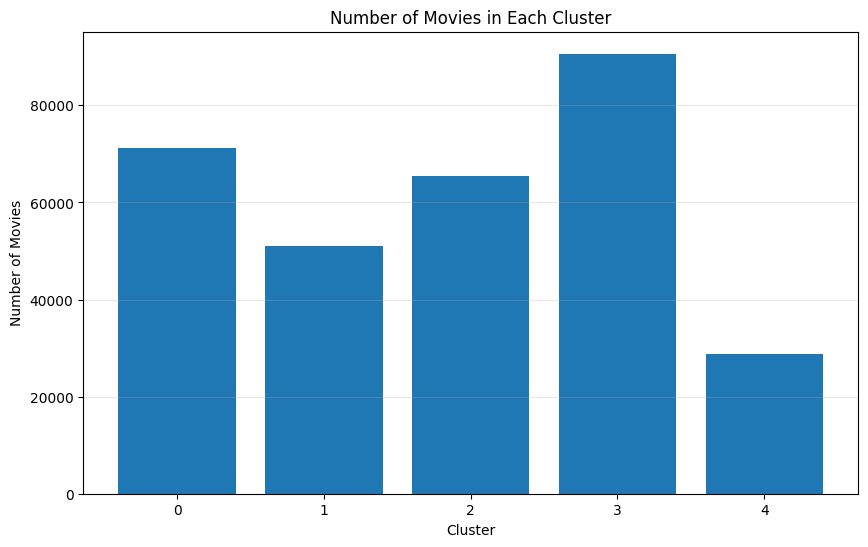

In [21]:
# Visualize the number of movies in each cluster

plt.figure(figsize=(10, 6))

plt.bar(
    cluster_sizes.index.astype(str),
    cluster_sizes.values
)

plt.title("Number of Movies in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Movies")

plt.grid(axis="y", alpha=0.3)

plt.show()

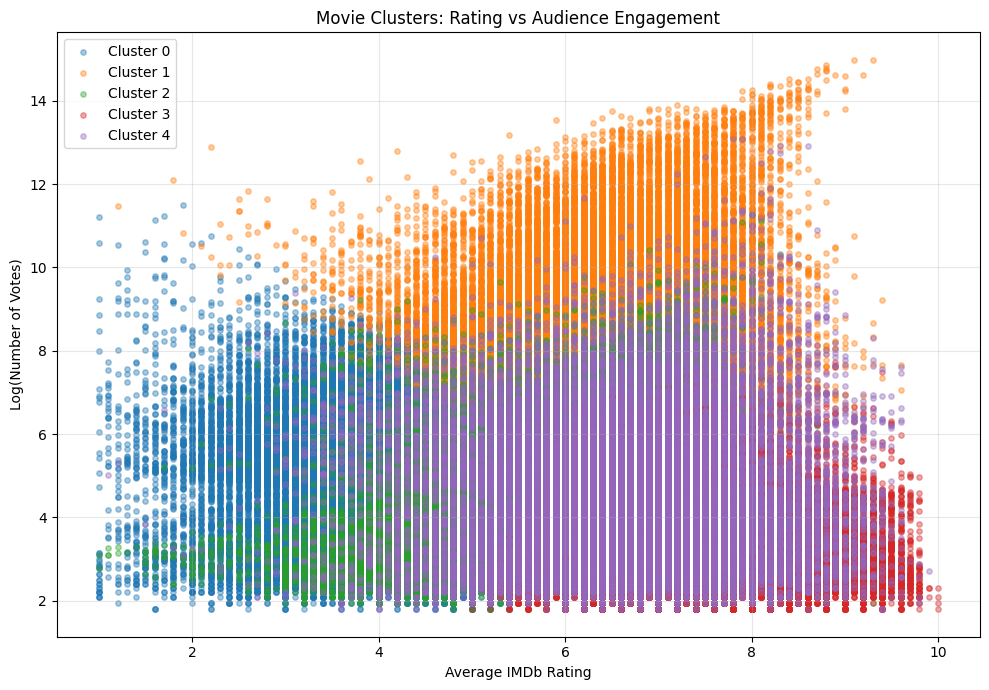

In [22]:
# Rating vs Audience Engagement by Cluster

plt.figure(figsize=(10, 7))

for cluster in sorted(cluster_df["cluster"].unique()):

    cluster_data = cluster_df[
        cluster_df["cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["averageRating"],
        cluster_data["log_numVotes"],
        label=f"Cluster {cluster}",
        alpha=0.4,
        s=15
    )

plt.title("Movie Clusters: Rating vs Audience Engagement")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Log(Number of Votes)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Compare each cluster with the overall dataset

overall_profile = cluster_df[
    features_for_clustering
].mean()

cluster_comparison = cluster_profiles.subtract(
    overall_profile,
    axis="columns"
).round(2)

print("Cluster Difference from Overall Average:")
display(cluster_comparison)

Cluster Difference from Overall Average:


,averageRating,log_numVotes,runtimeMinutes,year
cluster,,,,
0,-1.60,-0.09,-3.13,11.54
1,0.31,3.31,9.85,7.73
2,-0.17,-0.55,-9.24,-40.46
3,1.07,-1.34,-11.61,14.26
4,0.47,-0.19,47.93,4.93


In [26]:
# Save machine learning clustering results

# 1. Save movie-level cluster assignments
cluster_df.to_csv(
    "../data/processed/movie_clusters.csv",
    index=False
)

# 2. Save cluster summary
cluster_summary.to_csv(
    "../data/processed/movie_cluster_summary.csv",
    index=False
)

# 3. Recreate cluster evaluation using the results obtained earlier
cluster_evaluation = pd.DataFrame({
    "k": [2, 3, 4, 5, 6, 7, 8],
    "inertia": [
        973880.2269,
        766980.8457,
        620256.0934,
        535803.0854,
        493548.5533,
        463165.1114,
        434646.3375
    ],
    "silhouette_score": [
        0.2126,
        0.2521,
        0.2728,
        0.2853,
        0.2283,
        0.2143,
        0.2050
    ]
})

# 4. Save evaluation results
cluster_evaluation.to_csv(
    "../data/processed/cluster_evaluation.csv",
    index=False
)

print("Machine learning results saved successfully.")
print("\nFiles created:")
print("- movie_clusters.csv")
print("- movie_cluster_summary.csv")
print("- cluster_evaluation.csv")

Machine learning results saved successfully.

Files created:
- movie_clusters.csv
- movie_cluster_summary.csv
- cluster_evaluation.csv


# Phase 11: Advanced Genre Insights — Final Findings & Conclusion

## Key Findings

### 1. Movie Clustering
K-Means clustering was applied to group movies based on average IMDb rating, audience engagement, runtime, and release year.

After comparing multiple values of K using inertia and silhouette score, **K = 5** was selected as the optimal number of clusters.

The highest silhouette score among the tested configurations was **0.2853 at K = 5**.

### 2. Cluster Characteristics
The five clusters represent different movie profiles based on their rating, audience engagement, runtime, and release period.

Cluster comparison revealed meaningful differences between groups, including clusters containing:
- Lower-rated movies
- Highly audience-engaged movies
- Higher-rated movies
- Older movie profiles
- Movies with significantly longer runtimes

### 3. Audience Engagement
The clustering analysis showed that audience engagement varies considerably across movie groups.

The use of `log_numVotes` reduced the effect of extreme vote counts and allowed the clustering algorithm to identify more balanced patterns.

### 4. Advanced Analytical Insight
The clustering results complement the earlier exploratory and statistical analyses by providing an **unsupervised machine learning perspective**.

Instead of analyzing movies only by individual variables or genres, K-Means identifies groups of movies that share similar characteristics across multiple numerical features.

## Final Conclusion

Phase 11 extended the Movie Genre Evolution Analyzer from descriptive and statistical analysis to machine learning-based analysis.

K-Means clustering successfully segmented the movie dataset into **five distinct clusters** using rating, audience engagement, runtime, and release year.

The analysis demonstrates that movies can be grouped into meaningful profiles based on multiple characteristics simultaneously. These clusters provide an additional perspective for understanding movie patterns and complement the genre evolution, genre combination, and statistical findings from previous phases.

Overall, the machine learning analysis strengthens the project by demonstrating the practical application of **Scikit-learn, feature transformation, feature standardization, K-Means clustering, inertia analysis, and silhouette evaluation** to a large real-world movie dataset.